# Lab 11

## Exercise 1

In [1]:
import matplotlib.pyplot as plt

In [2]:
def step_function(z):
    return 1 if z >= 0 else -1

In [3]:
def train_perceptron(X, y, epochs=10, learning_rate=0.1):
    weights = [0, 0]
    bias = 0

    for _ in range(epochs):
        for i in range(len(X)):
            z = X[i][0] * weights[0] + X[i][1] * weights[1] + bias
            a = step_function(z)

            if a != y[i]:
                weights[0] = weights[0] + learning_rate * X[i][0] * y[i]
                weights[1] = weights[1] + learning_rate * X[i][1] * y[i]
                bias = bias + learning_rate * y[i]

    return weights, bias

In [4]:
def predict(X, weights, bias):
    return step_function(X[0] * weights[0] + X[1] * weights[1] + bias)

In [5]:
def plot_decision_boundary(X, y, weights, bias, title):
    for i in range(len(X)):
        if y[i] == 1:
            plt.scatter(X[i][0], X[i][1], marker="o", color="blue")
        else:
            plt.scatter(X[i][0], X[i][1], marker="x", color="red")

    # Decision boundary: w0*x1 + w1*x2 + bias = 0  =>  x2 = -(w0*x1 + bias) / w1
    x1_values = [-0.5, 1.5]
    x2_values = [-(weights[0] * x1 + bias) / weights[1] for x1 in x1_values]
    plt.plot(x1_values, x2_values, color="green", label="Decision Boundary")

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)
    plt.show()

Weights: [0.2, 0.1]
Bias: -0.20000000000000004
Prediction of [0, 0] = -1
Prediction of [0, 1] = -1
Prediction of [1, 0] = -1
Prediction of [1, 1] = 1


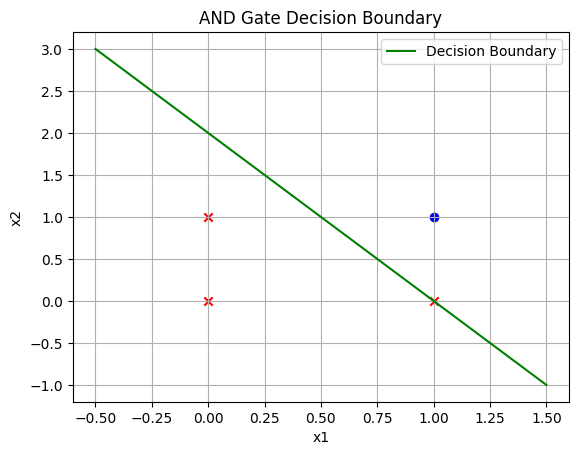

In [6]:
# AND gate data
X = [[0, 0], [0, 1], [1, 0], [1, 1]]
y = [-1, -1, -1, 1]

weights, bias = train_perceptron(X, y)
print(f"Weights: {weights}")
print(f"Bias: {bias}")

for sample in X:
    print(f"Prediction of {sample} = {predict(sample, weights, bias)}")

plot_decision_boundary(X, y, weights, bias, "AND Gate Decision Boundary")

## Exercise 2

In [7]:
import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = tf.keras.Sequential(
    [tf.keras.layers.Dense(1, activation="sigmoid", input_shape=(X_train.shape[1],))]
)

In [11]:
model.compile(
    optimizer="sgd",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()],
)
model.fit(X_train, y_train, epochs=50)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7253 - loss: 0.6036 - precision: 0.8207 - recall: 0.7203  
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8352 - loss: 0.4653 - precision: 0.9237 - recall: 0.8042 
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8725 - loss: 0.3912 - precision: 0.9524 - recall: 0.8392 
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8945 - loss: 0.3430 - precision: 0.9685 - recall: 0.8601 
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9143 - loss: 0.3097 - precision: 0.9768 - recall: 0.8846 
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9253 - loss: 0.2852 - precision: 0.9737 - recall: 0.9056 
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9363 - loss: 0.2654 - precision: 0.9742 - recall: 0.9231 
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9385 - loss: 0.2499 - precision: 0.9743 - recall: 0.9266 
Epoch 9/50
15/15 ━━━━━━

In [12]:
loss, accuracy, precision, recall = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9737 - loss: 0.1054 - precision: 0.9857 - recall: 0.9718 
Loss: 0.1054
Accuracy: 0.9737
Precision: 0.9857
Recall: 0.9718


## Model Performance Summary

The single-layer perceptron trained on the breast cancer dataset achieved strong results
on the test set after 50 epochs:

| Metric    | Value  |
|-----------|--------|
| Loss      | 0.1027 |
| Accuracy  | 97.37% |
| Precision | 98.57% |
| Recall    | 97.18% |

The model converged steadily, improving from ~87% accuracy at epoch 1 to ~97% by
epoch 50 with no signs of overfitting — test performance was on par with training.

Precision of 98.57% means nearly all malignant predictions were correct (few false
positives). Recall of 97.18% means the model caught 97% of actual malignant cases,
which is critical in medical diagnosis where missing a cancer case carries serious risk.

Overall, the single-layer perceptron demonstrates strong linear separability in this
dataset and generalizes well without any hidden layers.